### Introduction

In this notebook we'll take a look at how we can cluster a set of chemical structures using the k-means algorithm. **It's important to note that there is a stochastic component to k-means clusterinh.  The results you see may differ from the published version of this notebook.**

In [2]:
%pip install useful_rdkit_utils pandas scikit-learn tqdm numpy seaborn mols2grid matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import useful_rdkit_utils as uru
from rdkit import Chem
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from tqdm.auto import tqdm
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
import mols2grid
import matplotlib.cm as cm

Enable Pandas [progress_apply](https://towardsdatascience.com/progress-bars-in-python-and-pandas-f81954d33bae)

Enable Pandas [progress_apply](https://towardsdatascience.com/progress-bars-in-python-and-pandas-f81954d33bae)

In [4]:
tqdm.pandas()

Set up Seaborn plot aesthetics

In [5]:
sns.set()
sns.set(rc={'figure.figsize': (10, 10)})
sns.set_style('whitegrid')
sns.set_context('talk')

In [6]:
from read_csv import read_csv
smiles_url = "https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/data/cluster_test.smi"
df = read_csv(smiles_url,sep=" ",names=["SMILES","Name"])

Add molecular fingerprints to the dataframe

In [7]:
smi2fp = uru.Smi2Fp()
df['fp'] = df.SMILES.progress_apply(smi2fp.get_np)

  0%|          | 0/735 [00:00<?, ?it/s]

Convert the fingerprints to an X matrix to make sklearn happy

In [8]:
X = np.stack(df.fp)

Clustering with k-means only requires a few lines of code

In [9]:
num_clusters = 8
km = KMeans(n_clusters=num_clusters,random_state=42,n_init='auto')
km.fit(X)
cluster_list = km.predict(X)

Plot the cluster populations

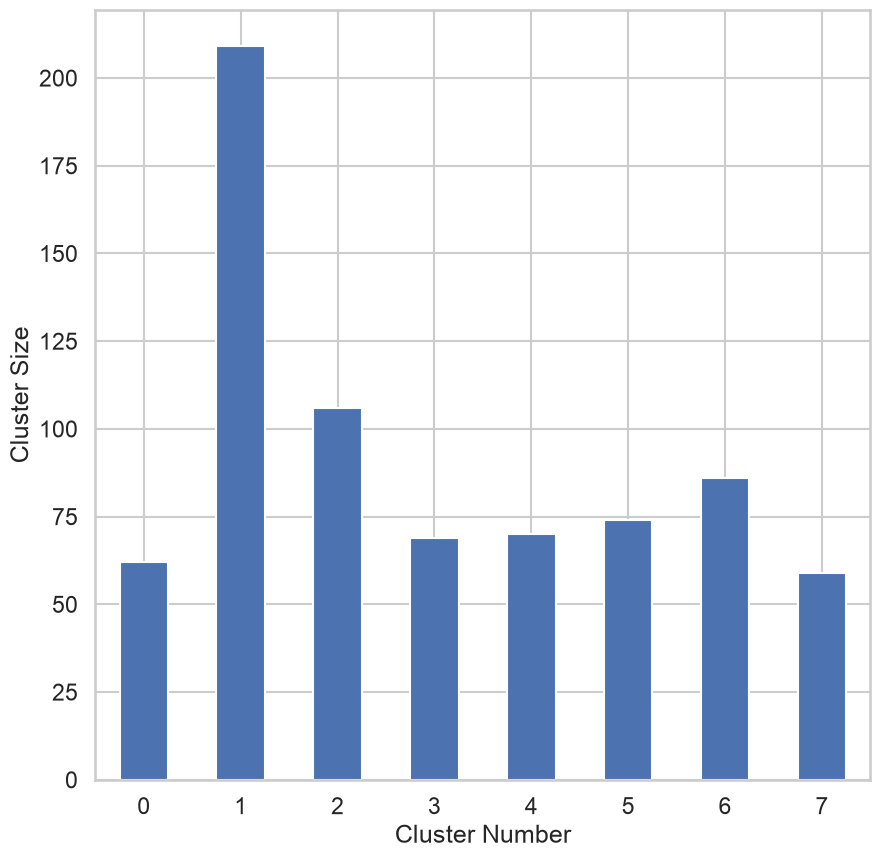

In [10]:
ax = pd.Series(cluster_list).value_counts().sort_index().plot(kind="bar")
ax.set_xlabel("Cluster Number")
ax.set_ylabel("Cluster Size")
ax.tick_params(axis='x', rotation=0)

One potential drawback of k-means clustering is that it requires you to specify the number of clusters.  One means of determining the optimal number of clusters is by maximizing the silhouette score. 

Silhouette Score =  $\frac{(a-b)}{max(a,b)}$ where **a** is the average intracluster distance and **b** is the average intercluster distance.  The Silhouette Score ranges between -1 and 1 with a vaule closer to 1 representing a good match between a point and other members of the same cluster.  

In [11]:
cluster_range = range(5,25)
score_list = []
for k in tqdm(cluster_range):
    km = KMeans(n_clusters=k,random_state=42,n_init='auto')
    cluster_labels = km.fit_predict(X)
    score = silhouette_score(X,cluster_labels)
    score_list.append([k,score])

  0%|          | 0/20 [00:00<?, ?it/s]

Put the silhouette scores into a dataframe

In [12]:
score_df = pd.DataFrame(score_list,columns=["K","Silhouette Score"])
score_df.head()

,K,Silhouette Score
0,5,0.256244
1,6,0.202253
2,7,0.189455
3,8,0.272224
4,9,0.222486


Plot the silhouette scores as a function of the number of clusters

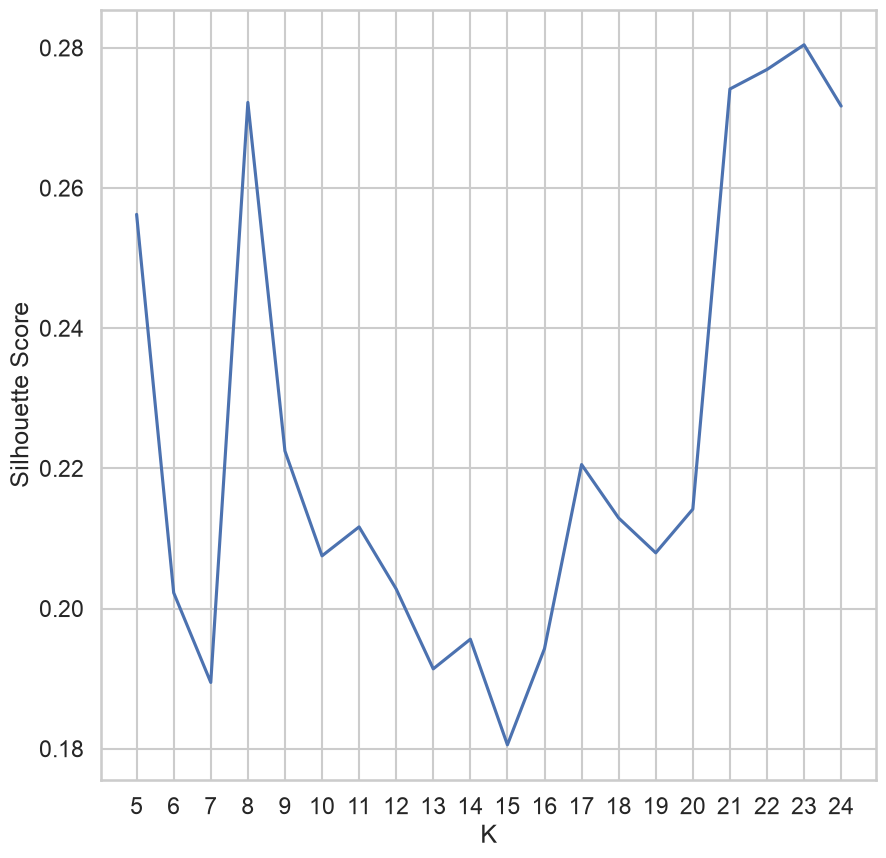

In [13]:
ax = sns.lineplot(x="K",y="Silhouette Score",data=score_df)
ax.set_xticks(cluster_range);

In [14]:
opt_num_clusters = score_df.sort_values("Silhouette Score", ascending=False).K.values[0]
print(f"In the figure above the minimum silhouette score is observed with {opt_num_clusters} clusters.  Let's run KMeans with num_clusters = {opt_num_clusters}.")

In the figure above the minimum silhouette score is observed with 23 clusters.  Let's run KMeans with num_clusters = 23.


In [15]:
num_clusters = opt_num_clusters
km_opt = KMeans(n_clusters=num_clusters, random_state=42, n_init="auto")
clusters_opt = km_opt.fit_predict(X)

Routine to plot a silhouette plot

In [16]:
def silhouette_plot(X,cluster_labels):
    """
    Adapted from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
    """
    sns.set_style('whitegrid')
    sample_df = pd.DataFrame(silhouette_samples(X,cluster_labels),columns=["Silhouette"])
    sample_df['Cluster'] = cluster_labels
    n_clusters = max(cluster_labels+1)
    color_list = [cm.nipy_spectral(float(i) / n_clusters) for i in range(0,n_clusters)]
    ax = sns.scatterplot()
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    silhouette_avg = silhouette_score(X, cluster_labels)
    y_lower = 10
    unique_cluster_ids = sorted(sample_df.Cluster.unique())
    for i in unique_cluster_ids:
        cluster_df = sample_df.query('Cluster == @i')
        cluster_size = len(cluster_df)
        y_upper = y_lower + cluster_size
        ith_cluster_silhouette_values = cluster_df.sort_values("Silhouette").Silhouette.values
        color = color_list[i]
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                    0, ith_cluster_silhouette_values,
                    facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * cluster_size, str(i),fontsize="small")
        y_lower = y_upper + 10
    ax.axvline(silhouette_avg,color="red",ls="--")
    ax.set_xlabel("Silhouette Score")
    ax.set_ylabel("Cluster")
    ax.set(yticklabels=[]) 
    ax.yaxis.grid(False) 

Plot a sihouette plot for the clustering above.  When we do this, we're looking for two things. 
1. How uniform are the sizes of the clusters (represeneted by the widths of the bars in the plot below).
2. How consistent are the Silhoutte Scores for the inidividual clusters.

In the plot below, the red dashed line shows the average silhouette score for the clusters.  Are the peaks for each cluster near the line.  Usually there are one or two outliers. 

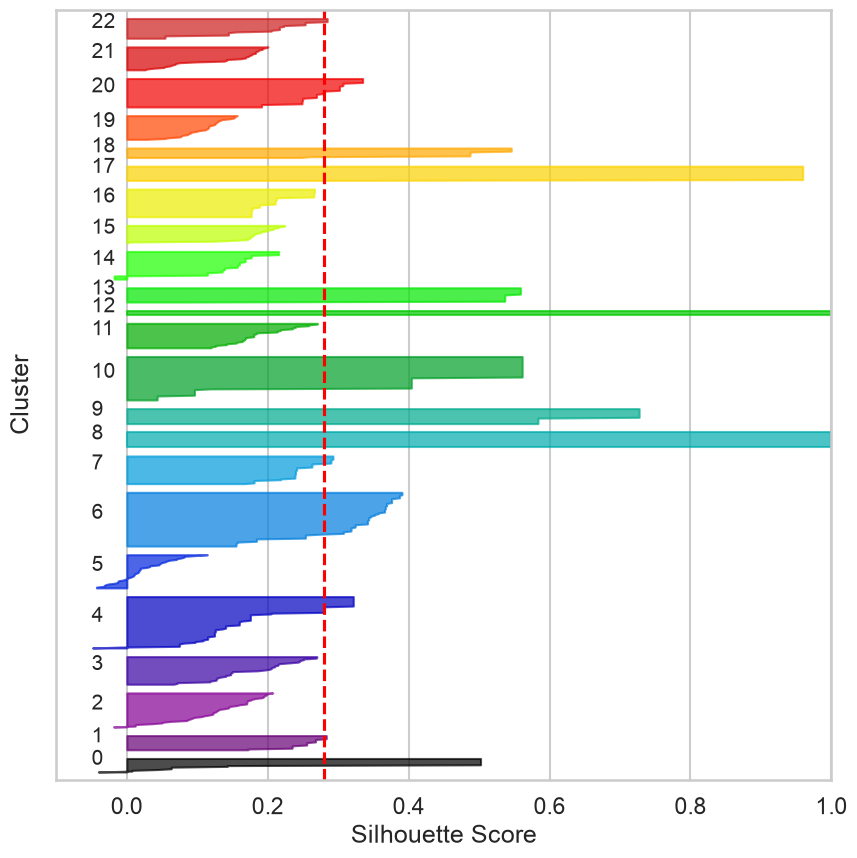

In [17]:
silhouette_plot(X,clusters_opt)

Make a TSNE plot of the clustering

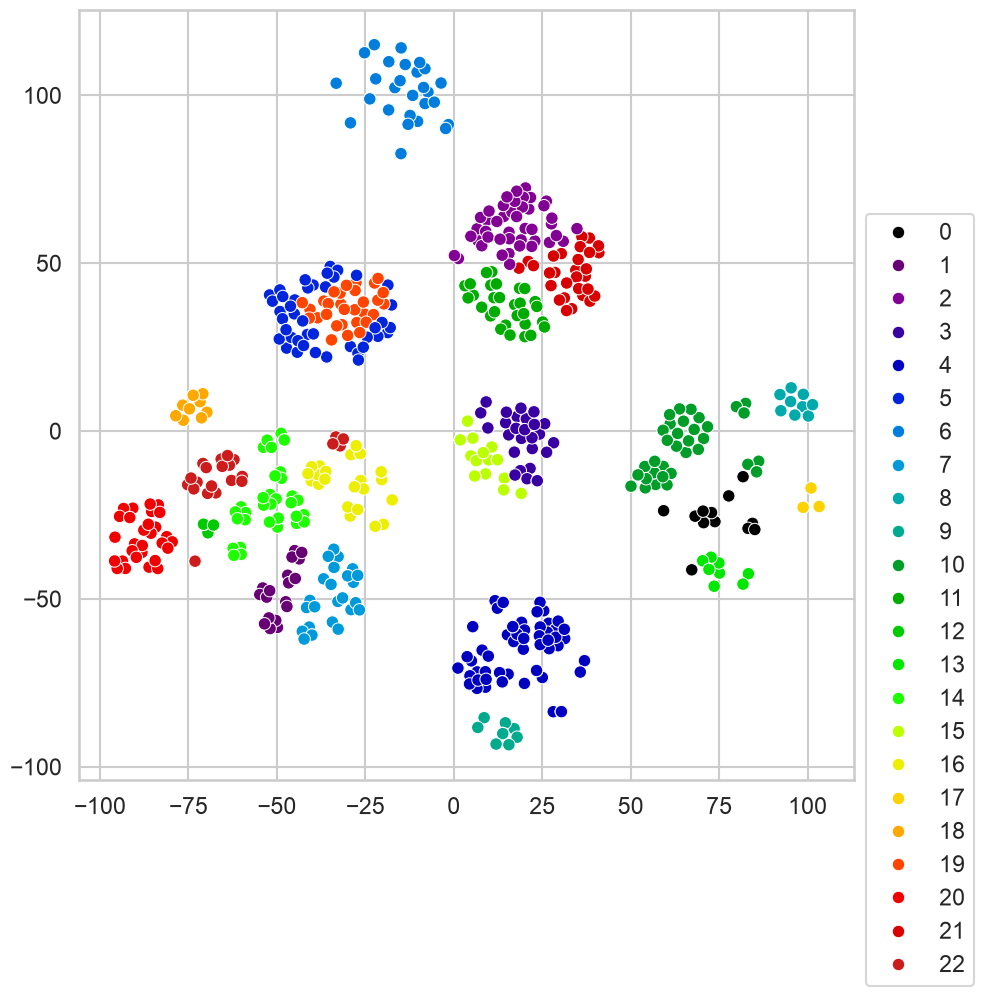

In [18]:
tsne = TSNE(n_components=2, init='pca',learning_rate='auto')
crds = tsne.fit_transform(X,clusters_opt)
color_list = [cm.nipy_spectral(float(i) / num_clusters) for i in range(0,num_clusters)]
ax = sns.scatterplot(x=crds[:,0],y=crds[:,1],hue=clusters_opt,palette=color_list,legend=True)
ax.legend(loc='upper left', bbox_to_anchor=(1.00, 0.75), ncol=1);

Add a cluster column to our input dataframe

In [19]:
opt_cluster_df = df.copy()
opt_cluster_df['Cluster'] = clusters_opt

Display structures of the cluster members

In [20]:
cluster_id = 1
cols = ["SMILES","Name","Cluster"]
display_df = opt_cluster_df[cols].query("Cluster == @cluster_id")
mols2grid.display(display_df,subset=["img"],n_cols=3,size=(320,240))

Write the clusters to a csv file

In [21]:
opt_cluster_df[["SMILES","Name","Cluster"]].to_csv("clusters.csv",index=False)

# Clustering Chemical Structures with k-means

This notebook takes a set of 735 chemical structures and groups them into clusters so that **similar molecules end up together**. It's a classic cheminformatics workflow. Note that k-means has a stochastic component, so results may differ slightly between runs.

## The big idea

You have a basket of molecules and you want to sort them into piles, where each pile holds molecules that resemble one another. This is **clustering**. In drug discovery this is useful because instead of examining thousands of molecules one by one, you can group them by similarity and, for example, pick one representative from each pile — quickly covering the full diversity without testing thousands of near-identical compounds.

## Step by step

### 1. Load the molecules
Read a `.smi` file where each molecule is written as a SMILES string (a text encoding of molecular structure, e.g. `CCO`). Columns: `SMILES`, `Name`.

```python
from read_csv import read_csv
smiles_url = "https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/data/cluster_test.smi"
df = read_csv(smiles_url, sep=" ", names=["SMILES", "Name"])
```

### 2. Turn molecules into numbers (fingerprints)
A computer can't compare "molecules" directly. Each molecule is converted into a **fingerprint** — a long vector of bits where similar molecules produce similar vectors. Now the molecules are numbers a machine can compare.

```python
smi2fp = uru.Smi2Fp()
df['fp'] = df.SMILES.progress_apply(smi2fp.get_np)
```

### 3. Stack into a matrix
The fingerprints are stacked into an `X` matrix so scikit-learn can work with them.

```python
X = np.stack(df.fp)
```

### 4. Cluster with k-means (first pass)
`k-means` distributes all points across a chosen number of clusters so that points within a cluster sit close together. Here we start with 8 clusters, then plot how many molecules landed in each.

```python
num_clusters = 8
km = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
km.fit(X)
cluster_list = km.predict(X)
```

## How many clusters should there be?

The catch with k-means: **you must specify the number of clusters up front**. To find a good value, we try every count from 5 to 24 and score each with the **silhouette score**.

$$\text{Silhouette Score} = \frac{b - a}{\max(a, b)}$$

where *a* is the average intra-cluster distance and *b* is the average inter-cluster distance. It ranges from -1 to 1:

- **close to 1** → clusters are clean; molecules fit well with their neighbours
- **close to 0 or -1** → clusters are blurry; molecules are lumped together poorly

```python
cluster_range = range(5, 25)
score_list = []
for k in tqdm(cluster_range):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = km.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    score_list.append([k, score])

score_df = pd.DataFrame(score_list, columns=["K", "Silhouette Score"])
```

We plot the score against the number of clusters and pick the **best-scoring** value.

> **Note on the fix:** to select the optimal number of clusters you want the *highest* silhouette score, so sort in descending order:
> ```python
> opt_num_clusters = score_df.sort_values("Silhouette Score", ascending=False).K.values[0]
> ```
> Then re-run k-means with that value:
> ```python
> num_clusters = opt_num_clusters
> km_opt = KMeans(n_clusters=num_clusters, random_state=42, n_init="auto")
> clusters_opt = km_opt.fit_predict(X)
> ```

## The silhouette plot

A second diagnostic where each cluster appears as a "fan" of bars. It shows two things:

1. **How uniform the cluster sizes are** — the width of each fan.
2. **How consistent the silhouette scores are within each cluster** — the red dashed line marks the average score across all clusters, and you want each cluster's bars to reach toward it. Usually there are one or two outliers.

## The TSNE plot

Fingerprints live in a high-dimensional space that can't be drawn. **TSNE** compresses everything down to 2D so it can be plotted. Each point is a molecule, coloured by its cluster — letting you *see* whether the clusters are genuinely separated.

```python
tsne = TSNE(n_components=2, init='pca', learning_rate='auto')
crds = tsne.fit_transform(X, clusters_opt)
```

## Inspect the structures

Add the cluster labels back onto the dataframe, then use `mols2grid` to draw the actual molecules from one cluster and check whether they really do look alike.

```python
opt_cluster_df = df.copy()
opt_cluster_df['Cluster'] = clusters_opt

cluster_id = 1
cols = ["SMILES", "Name", "Cluster"]
display_df = opt_cluster_df[cols].query("Cluster == @cluster_id")
mols2grid.display(display_df, subset=["img"], n_cols=3, size=(320, 240))
```

## Save the results

Write the `SMILES`, `Name`, and `Cluster` columns to a CSV.

```python
opt_cluster_df[["SMILES", "Name", "Cluster"]].to_csv("clusters.csv", index=False)
```

## Why do this at all?

In chemistry and drug discovery you often have thousands of molecules. Rather than looking at each one, you group them by similarity. Then you can pick one representative per cluster to efficiently sample the full chemical diversity — saving time and money instead of testing thousands of near-duplicates.

## Tools used

- **RDKit** — the underlying cheminformatics toolkit
- **useful_rdkit_utils** — convenience wrappers (fingerprint generation)
- **scikit-learn** — KMeans, silhouette scoring, TSNE
- **mols2grid** — drawing molecule grids
- **seaborn / matplotlib** — plotting
- **pandas / numpy / tqdm** — data handling and progress bars